# Part 3A : Hurricane Florence
**What is JSON?** Use the internet to find an answer.
> JSON is a light weight, human readable text format for storing and exchanging data. JSON's full form is JavaScript Object Notation. It can be used in any language even though it originated from JavaScript. It's widely used for web APIs, where serves and clients exhange structured data. 


In [67]:
# reimport for simplicity

import matplotlib.pyplot as plt
import pandas as pd
import geopandas as gpd
country = gpd.read_file('gz_2010_us_040_00_5m.json')
country.head()

,GEO_ID,STATE,NAME,LSAD,CENSUSAREA,geometry
0,0400000US01,01,Alabama,,50645.326,"MULTIPOLYGON (((-88.12466 30.28364, -88.08681 ..."
1,0400000US02,02,Alaska,,570640.950,"MULTIPOLYGON (((-166.10574 53.98861, -166.0752..."
2,0400000US04,04,Arizona,,113594.084,"POLYGON ((-112.53859 37.00067, -112.53454 37.0..."
3,0400000US05,05,Arkansas,,52035.477,"POLYGON ((-94.04296 33.01922, -94.04304 33.079..."
4,0400000US06,06,California,,155779.220,"MULTIPOLYGON (((-122.42144 37.86997, -122.4213..."


<Axes: >

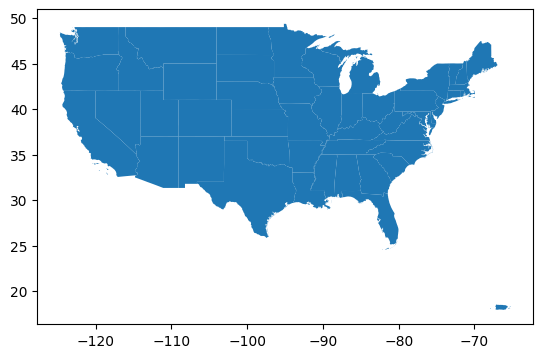

In [68]:
country = country[(country['NAME'] != 'Alaska') & (country['NAME'] != 'Hawaii')]
country.plot()

<Axes: >

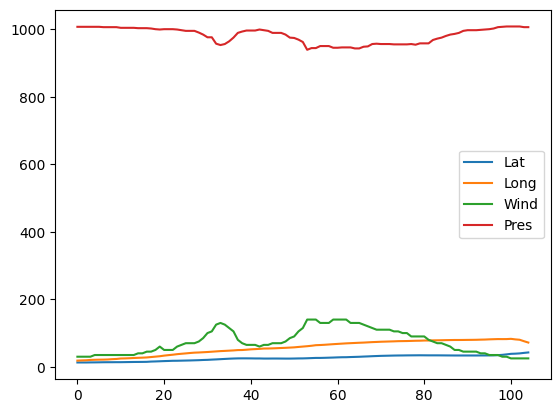

In [69]:
# create a Pandas DataFrame and plot the location over time
florence = pd.read_csv('stormhistory.csv')
florence.plot()

# Part 3B : Adding a column
**Re-write the code in the cell below**, but do it without using a comprehension and no zip. Use a for-loop and the `.loc` method to get the data. Print out some stuff to convince yourself that they are identical!
```python

florence["coordinates_loop"] = None
for in in florence.index:
    longitude = florence.loc[i, "Long"]
    latitude = florence.loc[i, "Lat"]

    florence.loc[i, "coordinates_loop"] = Point(-lon, lat)
print(florence[["coordinates", "coordinates_loop"]].head())
```

> Note that the -long is required because Longitude WEST is represented with negative
> values, and the data in stormhistory omits the negative value.

In [70]:
from shapely.geometry import Point

# Add new-lines for clarity
florence['coordinates'] = [
    Point(-long, lat) 
    for long, lat 
    in zip(florence['Long'], florence['Lat'])
]
    

# Part 3C : Plot the path
Using the florence geodataframe and the figure provided in the code below, **plot the US and the hurricane's path** on the same axis. Get the figure to look like the one presented in the slidedeck.  

Recall that the US map is in the country identifier (of type geodataframe) which has already been filtered down to just the US.   
Hints:  
* change the size of the plot using the named parameter 'markersize'
* set the color of the plots using the named parameter 'color'

Text(0.5, 1.0, 'Hurriance Florence Path')

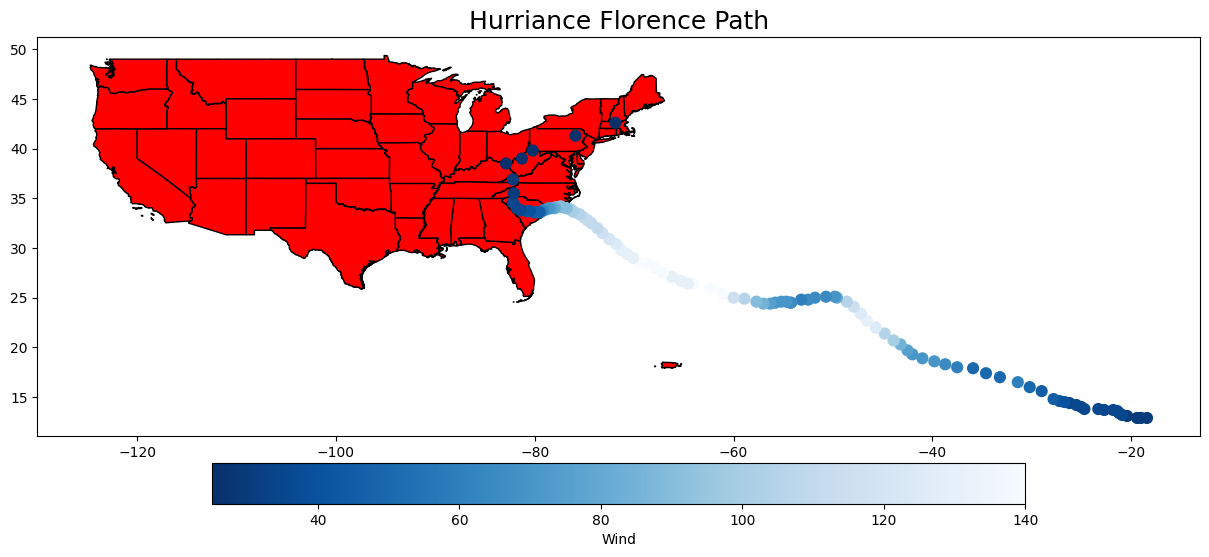

In [71]:
florence = gpd.GeoDataFrame(florence, geometry='coordinates')
fig, ax = plt.subplots(1, figsize=(15, 7))

country.plot(ax = ax, color = "red", edgecolor = "black")
florence.plot(ax = ax, column = "Wind", cmap = "Blues_r", markersize = 60, legend = True, legend_kwds={"label": "Wind", "orientation": "horizontal", "shrink" : 0.7, "pad" : 0.05})
ax.set_title("Hurriance Florence Path", fontsize = 18)



### Quite the Challenge

![Challenge](challenge.PNG)

Can you get the following?

* Add the Wind velocity into the map by using the velocity to color the points. 
    * _HINT_: Use the named argument 'column' (not 'color')
    * _HINT_: Use the named argument 'cmap' to set the [theme](https://matplotlib.org/stable/tutorials/colors/colormaps.html) of the color
* Add a legend to show wind velocity values, position it under the graph, and label it Wind.
    * _HINT_: Use the named argument 'legend_kwds' and see the arguments for [colorbar](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.colorbar.html#matplotlib.pyplot.colorbar) to know what key/value pairs are available.